<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Proyecto del Curso</center></b><h2>
<h3><b><center>Disco de acreción alrededor de un agujero negro</center></b><h3>
<h7><center><i>Última actualización del profesor</b>: Viernes 20 de marzo de 2026, 2:00 pm</i></center><h7>
</p>

## Enunciado

<center>
<img src="https://cdn.sci.news/images/2021/02/image_9386-AT2019dsg.jpg" align="center" width="100%"></center>

Muchos objetos astrofísicos fascinantes (núcleos galácticos activos, hipernovas, binarias de rayos X) pueden explicarse con los fenómenos que ocurren en los denominados discos de acreción alrededor de agujeros negros. En este proyecto usaremos lo visto en el curso de Relatividad y Gravitación para estudiar esos fenómenos.

El objetivo de este trabajo es desarrollar simulaciones, cálculos útiles, predicciones sobre el comportamiento de las partículas en un disco de acreción. La idea es poner en práctica lo visto en el curso, tanto en las partes de relatividad especial como en las de relatividad general, para estudiar estos sistemas.

## Algunas ideas

Existen muchas maneras de aplicar la teoría que veremos en el curso en este problema y no queremos sesgar tu elección de los temas o cálculos que quieras escoger para aplicarla. Sin embargo aquí van algunas ideas de cálculos que se podrían hacer:
- Simulación del movimiento de muchas partículas alrededor del agujero negro usando, inicialmente, la dinámica newtoniana.
- Cálculo y representación gráfica de la luz emitida por el disco y observada desde distinto ángulos, incluyendo los efectos de beaming y desplazamiento espectral.
- Simulación del jet del agujero negro usando partículas cargadas moviéndose en el campo del jet.
- Cálculo de la trayectoria de fotones para visualizar el disco de acreción desde distintos ángulos.
- Cálculo de las trayectorias de partículas usando la métrica de Schwarzschild y de Kerr.

## Entregables

El entregable del proyecto es **un notebook final de Jupyter** con una descripción de la teoría básica que uses, los experimentos numéricos que hayas realizado y las conclusiones a las que llegues con esos experimentos. Por supuesto puedes desarrollar otros programas y notebooks paralelos, pero se revisará el notebook con el reporte final.

Adicionalmente se deberá entregar **un repositorio de GitHub** que tenga todos los archivos, datos, notebooks, programas usados para este propósito. El notebook debe estar alojado en el repositorio.

## Criterios de evaluación

Una vez entregues el proyecto el profesor realizará una revisión del mismo y te lo devolverá con observaciones. En la segunda revisión emitirá un concepto cuantitativo del proyecto. Los criterios a evaluar serán:

- Correcta descripción y aplicación de la teoría.
- Originalidad de los experimentos numéricos.
- Conclusiones derivadas de los experimentos.
- Organización y extensión del reporte final.
- Ritmo de actualizaciones del repositorio de GitHub.

## Para tener en cuenta

- La solución presentada debe ser estrictamente individual. Evite resolver la tarea en parejas o en grupos que puede conducir a códigos o soluciones idénticos o muy similares.
- Los métodos y herramientas para resolver el problema deben ser los vistos en clase. El uso de herramientas diferentes puede ser una buena práctica en el mundo académico o laboral, pero en un curso puede también ser un indicio de un mal uso de las *asesorías* externa o del uso inapropiado de herramientas de Inteligencia Artificial (IA).
- El notebook entregado debe tener todos los resultados y gráficos, calculados y a la vista.  También debe ejecutarse completamente con `Ejecutar Todo` sin producir ningún error (verifique antes de entregar).
- El notebook debe tener explicaciones detalladas para cada paso del procedimiento usando celdas de texto. No debe poner una celda de código sin explicarla. En caso de incluir ecuaciones debe usar $\LaTeX$.

# **Proyecto Relatividad y Gravitación**

### **María Isabel Olarte García - CC 1034986320**

Librerías a utilizar:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#### **Movimiento de Partículas con Mecánica Newtoniana**

#### **Beaming Relativista**

In [3]:
def gamma_factor(beta):
    return 1 / np.sqrt(1 - beta**2)

def factor_beaming(theta, beta):
    return 1 / (gamma_factor(beta) * (1 - beta * np.cos(theta)))

def desplazamiento_espectral_cinematico(theta, beta, nu0):
    "Devuelve el cambio en la frecuencia debido al movimiento de la fuente"
    return factor_beaming(theta, beta) * nu0

def desplazamiento_espectral(theta, beta):
    "Devuelve el desplazamiento al rojo o al azul"
    return 1/factor_beaming(theta, beta) - 1

def aberracion_angular(theta_prima, beta):
    "Devuelve el ángulo observado en el marco del observador dado el ángulo en el marco de la fuente"
    cos_theta = (np.cos(theta_prima) + beta) / (1 + beta * np.cos(theta_prima))
    return np.arccos(cos_theta)

Factor de Beaming vs Ángulo para distintos $\beta$

Definimos algunos valores de $\beta = \frac{v}{c}$ para determinar cómo varía el factor de beaming en función de $\theta$

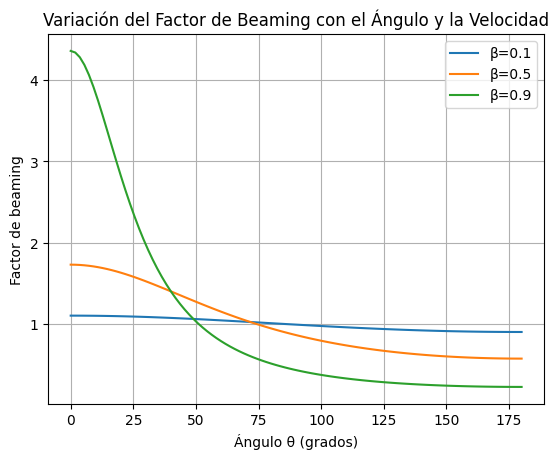

In [6]:
betas = np.array([0.1, 0.5, 0.9])
thetas_rad = np.linspace(0, np.pi, 100)
thetas_deg = np.degrees(thetas_rad)

for index, beta in enumerate(betas):
    factor_beaming_values = factor_beaming(thetas_rad, beta)
    plt.plot(thetas_deg, factor_beaming_values, label=f'β={beta}')

plt.xlabel('Ángulo θ (grados)')
plt.ylabel('Factor de beaming')
plt.title('Variación del Factor de Beaming con el Ángulo y la Velocidad')
plt.legend()
plt.grid(True)